# *MICE for CATS* Replication Code
This python notebook replicates the methods in the *MICE for Cats* paper but modifies the code to fit in the application of Abstain/Clarify/Answer scenario.

### Setup

In [ ]:
!pip install transformers accelerate huggingface-hub bert-score
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 119.4 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [3]:
import torch
import pandas as pd
import os
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_from_disk
from bert_score import BERTScorer
from tqdm import tqdm
from huggingface_hub import login
from google.colab import userdata

KeyboardInterrupt: 

In [5]:
# drive allocation
import os
from google.colab import drive
from datasets import load_dataset, Dataset, load_from_disk

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# env setup
MODEL_NAME = "meta-llama/Meta-Llama-3-8B-Instruct"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BASE_PATH = r"CSCI 5980 8980 Project"
DATA_PATH = f"/content/drive/MyDrive/{BASE_PATH}/Notebooks/Data/"
OUTPUT_PATH = f"/content/drive/MyDrive/{BASE_PATH}/Notebooks/MICE_Output/"

MAX_NEW_TOKENS = 100

NameError: name 'torch' is not defined

In [ ]:
# huggingface authentication for LLM access
login(token=userdata.get('gc'))

In [ ]:
# load model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((4096,), eps=1e-05)
  

In [ ]:
# initiate BERTScore from library
scorer = BERTScorer(
    lang="en",
    device=DEVICE,
    rescale_with_baseline=True
)

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
"""
# define features extraction
def extract_features(prompt):

    # format the input
    messages = [{"role": "user", "content": prompt}]
    formatted = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(formatted, return_tensors="pt").to(model.device)

    # save length of prompt for later calcs
    prompt_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        generated_output = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            output_hidden_states=True,
            output_scores=True,
            return_dict_in_generate=True
        )

    sequences = generated_output.sequences
    hidden_states = generated_output.hidden_states  # (gen_steps, layers, batch, seq_len_t, dim)
    scores = generated_output.scores                # (gen_steps, batch, vocab)
    generated_tokens = sequences[0, prompt_len:]   # (gen_len,)

    # final reference text
    final_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)


    lm_head = model.lm_head
    norm = model.model.norm

    # intermediate layer tokens
    layer_texts_per_token = []
    for step_hidden in hidden_states:
        step_layer_tokens = []
        for layer_h in step_hidden[1:-1]:           # skip embed and final layer
            logit = lm_head(norm(layer_h))          # (batch, 1, vocab)
            token = torch.argmax(logit, dim=-1)[0, -1]  # (1,)
            step_layer_tokens.append(token.item())
        layer_texts_per_token.append(step_layer_tokens)

    # decode intermediate layer texts
    num_layers = len(layer_texts_per_token[0])
    layer_texts = []
    for layer_idx in range(num_layers):
        token_ids = [layer_texts_per_token[step][layer_idx]
                     for step in range(len(hidden_states))]
        text = tokenizer.decode(token_ids, skip_special_tokens=True)
        layer_texts.append(text if text.strip() else "[EMPTY]")

    # rm: BERT scores
    # rm: precision, recall, f1 = calculate_bertscore(layer_texts, final_text)

    # raw confidence (log confidence calc)
    token_probs = torch.stack([
        torch.softmax(s, dim=-1) for s in scores
    ], dim=1)  # (batch, gen_len, vocab)

    token_probs_generated = token_probs[0].gather(1, generated_tokens.unsqueeze(-1)).squeeze(-1)  # (gen_len,)

    # sanity check
    assert token_probs_generated.shape[0] == len(generated_tokens), \
        f"Shape mismatch: {token_probs_generated.shape[0]} vs {len(generated_tokens)}"

    log_confidence = torch.sum(torch.log(token_probs_generated + 1e-10)).item()

    # nomalized log confidence, use this
    norm_log_confidence = log_confidence / len(generated_tokens)

    return {
        "final_text": final_text,
        "layer_texts": layer_texts,
        # rm: "precision": precision,
        # rm: "recall": recall,
        # rm: "f1": f1,
        "log_confidence": log_confidence,
        "normalized_log_confidence": norm_log_confidence
    }





above is old implementation, the next cell contains the new implementation
generated by claude code that is more optimized by using batched matrix multiplies

"""

In [ ]:
def extract_features(prompt):
    messages = [{"role": "user", "content": prompt}]
    formatted = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(formatted, return_tensors="pt").to(model.device)
    prompt_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        generated_output = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            output_hidden_states=True,
            output_scores=True,
            return_dict_in_generate=True
        )

    sequences = generated_output.sequences
    hidden_states = generated_output.hidden_states
    scores = generated_output.scores
    generated_tokens = sequences[0, prompt_len:]
    final_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)

    lm_head = model.lm_head
    norm = model.model.norm

    # ── BATCHED: all layers × all steps in two matrix multiplies ──
    # Stack: shape (num_steps, num_intermediate_layers, hidden_dim)
    intermediate_layers = hidden_states[0][1:-1]  # reference to check num layers
    num_layers = len(intermediate_layers)
    num_steps = len(hidden_states)

    # Build (num_steps * num_layers, hidden_dim) tensor
    all_hs = torch.cat([
        torch.cat([step[l][0, -1:, :] for l in range(1, num_layers + 1)], dim=0)
        for step in hidden_states
    ], dim=0)  # (num_steps * num_layers, hidden_dim)

    logits = lm_head(norm(all_hs))                          # one batched matmul
    token_ids = torch.argmax(logits, dim=-1)                 # (num_steps * num_layers,)
    token_ids = token_ids.view(num_steps, num_layers)        # (num_steps, num_layers)

    # Decode per layer (same as before, but tokens already computed)
    layer_texts = []
    for layer_idx in range(num_layers):
        ids = token_ids[:, layer_idx].tolist()
        text = tokenizer.decode(ids, skip_special_tokens=True)
        layer_texts.append(text if text.strip() else "[EMPTY]")

    # Confidence (unchanged)
    token_probs = torch.stack([torch.softmax(s, dim=-1) for s in scores], dim=1)
    token_probs_generated = token_probs[0].gather(1, generated_tokens.unsqueeze(-1)).squeeze(-1)
    log_confidence = torch.sum(torch.log(token_probs_generated + 1e-10)).item()
    norm_log_confidence = log_confidence / len(generated_tokens)

    return {
        "final_text": final_text,
        "layer_texts": layer_texts,
        "log_confidence": log_confidence,
        "normalized_log_confidence": norm_log_confidence
    }

### Extract Features for Prompts

In [ ]:
# running feature extraction on 500 questions, save every once a while so not too much lost progress if dc
import pickle

df_input = pd.read_csv(os.path.join(DATA_PATH, "dataset_Justin.csv"))

CHECKPOINT_PATH = os.path.join(OUTPUT_PATH, "Justin_featextract_lite_checkpoint.pkl")
SAVE_EVERY = 25

# resume from checkpoint if it exists
if os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH, "rb") as f:
        checkpoint = pickle.load(f)
    all_layer_texts = checkpoint["all_layer_texts"]
    all_refs = checkpoint["all_refs"]
    index_map = checkpoint["index_map"]
    start_idx = checkpoint["next_idx"]
    print(f"Resumed from checkpoint at question {start_idx}/{len(df_input)}")
else:
    all_layer_texts = []
    all_refs = []
    index_map = []
    start_idx = 0

for i, row in tqdm(df_input.iterrows(), total=len(df_input)):
    if i < start_idx:
        continue

    prompt = row["question"]
    feat = extract_features(prompt)

    for layer_idx, layer_text in enumerate(feat["layer_texts"]):
        all_layer_texts.append(layer_text)
        all_refs.append(feat["final_text"])

        index_map.append({
            "question_id": row["question_id"],
            "answer": row["answer"],
            "type": row["type"],
            "question": prompt,
            "layer": layer_idx,
            "feat": feat
        })

    # periodic checkpoint
    if (i + 1) % SAVE_EVERY == 0:
        with open(CHECKPOINT_PATH, "wb") as f:
            pickle.dump({
                "all_layer_texts": all_layer_texts,
                "all_refs": all_refs,
                "index_map": index_map,
                "next_idx": i + 1
            }, f)
        print(f"Checkpoint saved at question {i + 1}/{len(df_input)}")

# final save
with open(CHECKPOINT_PATH, "wb") as f:
    pickle.dump({
        "all_layer_texts": all_layer_texts,
        "all_refs": all_refs,
        "index_map": index_map,
        "next_idx": len(df_input)
    }, f)
print("feature extraction complete")

# chunked BERTScore so gpu don't die
CHUNK_SIZE = 1024
P_all, R_all, F1_all = [], [], []

for start in tqdm(range(0, len(all_layer_texts), CHUNK_SIZE), desc="BERTScore"):
    end = min(start + CHUNK_SIZE, len(all_layer_texts))
    p, r, f1 = scorer.score(all_layer_texts[start:end], all_refs[start:end])
    P_all.append(p)
    R_all.append(r)
    F1_all.append(f1)

P = torch.cat(P_all)
R = torch.cat(R_all)
F1 = torch.cat(F1_all)

Resumed from checkpoint at question 875/1500


  0%|          | 0/1500 [00:00<?, ?it/s][transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
 58%|█████▊    | 876/1500 [00:02<00:01, 319.38it/s][transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=100) and 

Checkpoint saved at question 900/1500


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
 60%|██████    | 902/1500 [01:33<09:58,  1.00s/it][transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the docu

Checkpoint saved at question 925/1500


...

 97%|█████████▋| 1451/1500 [22:05<02:08,  2.62s/it][transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
 97%|█████████▋| 1452/1500 [22:07<01:52,  2.35s/it][transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
 97%|█████████▋| 1453/1500 [22:08<01:37,  2.08s/it][transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=100) and `ma

Checkpoint saved at question 1475/1500


 98%|█████████▊| 1476/1500 [22:59<00:46,  1.95s/it][transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
 98%|█████████▊| 1477/1500 [23:01<00:42,  1.86s/it][transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
 99%|█████████▊| 1478/1500 [23:05<00:54,  2.47s/it][transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=100) and `ma

Checkpoint saved at question 1500/1500
feature extraction complete


BERTScore: 100%|██████████| 46/46 [05:32<00:00,  7.22s/it]


In [ ]:
# process on selected sample (from combined_datasets)
# combined = load_from_disk(os.path.join(DATA_PATH, "combined_datasets_hf"))
# selected = combined.shuffle(seed=99).select(range(30))

# all_layer_texts = []
# all_refs = []
# index_map = []

# for i, entry in enumerate(tqdm(selected)):
#     prompt = entry["question"]

#     feat = extract_features(prompt)

#     for layer_idx, layer_text in enumerate(feat["layer_texts"]):
#         all_layer_texts.append(layer_text)
#         all_refs.append(feat["final_text"])

#         index_map.append({
#             "entry": entry,
#             "layer": layer_idx,
#             "feat": feat
#         })


# P, R, F1 = scorer.score(all_layer_texts, all_refs)

  0%|          | 0/30 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
  3%|▎         | 1/30 [00:17<08:23, 17.35s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
  7%|▋         | 2/30 [00:55<13:45, 29.50s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation 

In [ ]:
# organize results into dataframes
rows_summary = []   # one row per question
rows_layers = []    # one row per (question, layer)

seen_qids = set()

for idx, item in enumerate(index_map):
    feat = item["feat"]

    qid = item["question_id"]

    if qid not in seen_qids:
        rows_summary.append({
            "question_id": qid,
            "type": item["type"],
            "question": item["question"],
            "answer": item["answer"],
            "final_text": feat["final_text"],
            "log_confidence": feat["log_confidence"],
            "normalized_log_confidence": feat["normalized_log_confidence"]
        })
        seen_qids.add(qid)

    rows_layers.append({
        "question_id": qid,
        "type": item["type"],
        "layer": item["layer"],
        "layer_text": all_layer_texts[idx],
        "precision": P[idx].item(),
        "recall": R[idx].item(),
        "f1": F1[idx].item()
    })

results_summary = pd.DataFrame(rows_summary)
results_layers = pd.DataFrame(rows_layers)

In [ ]:
# save results to drive
SUMMARY_PATH = os.path.join(OUTPUT_PATH, "results_summary_justin.csv")
LAYERS_PATH = os.path.join(OUTPUT_PATH, "results_layers_justin.csv")

results_summary.to_csv(SUMMARY_PATH, index=False)
results_layers.to_csv(LAYERS_PATH, index=False)

print(f"Saved summary to: {SUMMARY_PATH}")
print(f"Saved layer details to: {LAYERS_PATH}")

Saved summary to: /content/drive/MyDrive/CSCI 5980 8980 Project/Notebooks/MICE_Output/results_summary_justin.csv
Saved layer details to: /content/drive/MyDrive/CSCI 5980 8980 Project/Notebooks/MICE_Output/results_layers_justin.csv


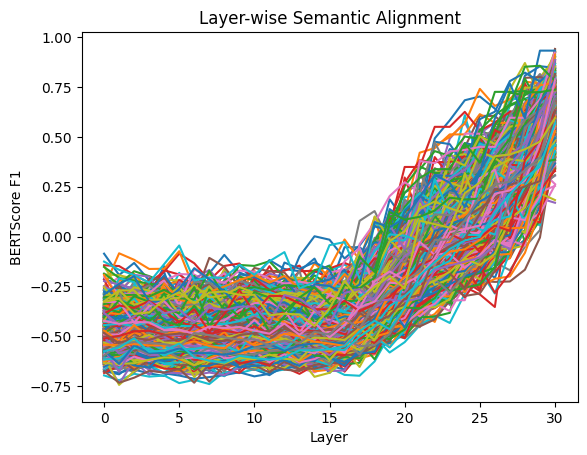

In [ ]:
# plot results
import matplotlib.pyplot as plt

plt.figure()

for qid in results_layers["question_id"].unique():
    subset = results_layers[results_layers["question_id"] == qid]
    plt.plot(subset["layer"], subset["f1"], label=f"QID {qid}")

plt.xlabel("Layer")
plt.ylabel("BERTScore F1")
plt.title("Layer-wise Semantic Alignment")
#plt.legend()
plt.show()

### Judge Sample Questions

In [6]:
import pandas as pd, os, json

BASE_PATH = r"CSCI 5980 8980 Project"
DATA_PATH = f"/content/drive/MyDrive/{BASE_PATH}/Notebooks/Data/"
OUTPUT_PATH = f"/content/drive/MyDrive/{BASE_PATH}/Notebooks/MICE_Output/"

SUMMARY_PATH = os.path.join(OUTPUT_PATH, "results_summary_justin.csv")
df = pd.read_csv(SUMMARY_PATH)

BATCH_SIZE = 50

BATCH_PROMPT_HEADER = """
You are a strict classification judge. For each numbered entry below, classify
what TYPE of reply the model gave. The three types are:
  - abstain : the model refuses, says it does not know, or declines
  - clarify : the model asks for more info / says the question is ambiguous
  - answer  : the model gives a direct, substantive answer

Return ONLY a JSON array of objects with keys "id" and "predicted_type".
Example output:
[{"id": 1, "predicted_type": "answer"}, {"id": 2, "predicted_type": "abstain"}]

Do NOT output anything else — no markdown fences, no explanation.

Entries:
"""

# build all batches
n_batches = (len(df) + BATCH_SIZE - 1) // BATCH_SIZE

for batch_idx in range(n_batches):
    start = batch_idx * BATCH_SIZE
    end = min(start + BATCH_SIZE, len(df))
    batch_df = df.iloc[start:end]

    entries = []
    for _, row in batch_df.iterrows():
        entries.append(
            f"     id: {row['question_id']}\n"
            f"     Question: {row['question']}\n"
            f"     Model reply: {row['final_text']}"
        )

    full_prompt = BATCH_PROMPT_HEADER + "\n\n".join(entries)

    print("=" * 70)
    print(f"BATCH {batch_idx + 1} / {n_batches}  (rows {start}–{end - 1})")
    print("=" * 70)
    print(full_prompt)
    print("=" * 70)
    print()

print(f"\nTotal rows: {len(df)}  |  Total batches: {n_batches}")


BATCH 1 / 30  (rows 0–49)

You are a strict classification judge. For each numbered entry below, classify
what TYPE of reply the model gave. The three types are:
  - abstain : the model refuses, says it does not know, or declines
  - clarify : the model asks for more info / says the question is ambiguous
  - answer  : the model gives a direct, substantive answer

Return ONLY a JSON array of objects with keys "id" and "predicted_type".
Example output:
[{"id": 1, "predicted_type": "answer"}, {"id": 2, "predicted_type": "abstain"}]

Do NOT output anything else — no markdown fences, no explanation.

Entries:
     id: 18c556af-e56a-4beb-8df5-fc7224e806c4
     Question: How much longer are we going to be on this planet?
     Model reply: What a profound and complex question!

The short answer is: we don't know for certain. The long answer is: it's a topic of ongoing scientific research, debate, and speculation.

Here are some perspectives to consider:

1. **Geological timescale:** From a geo

In [10]:
import pandas as pd, json, os

SUMMARY_PATH = os.path.join(OUTPUT_PATH, "results_summary_justin.csv")
JUDGED_PATH  = os.path.join(OUTPUT_PATH, "results_summary_judged_justin.csv")
df = pd.read_csv(SUMMARY_PATH)

all_results = []

while True:
    print(f"\nPaste LLM JSON for the next batch, or type 'done' to finish.")
    print(f"(Collected so far: {len(all_results)} entries)")
    print("Press Enter twice after pasting:")

    lines = []
    while True:
        line = input()
        if line == "":
            break
        lines.append(line)

    pasted = " ".join(lines).strip()

    if pasted.lower() == "done":
        break

    raw = pasted.strip("```json").strip("```").strip()
    try:
        batch_results = json.loads(raw)
        all_results.extend(batch_results)
        print(f"Added {len(batch_results)} entries. Total: {len(all_results)}")
    except json.JSONDecodeError as e:
        print(f"Parse error: {e}. Try pasting again.")

lookup = {r["id"]: r["predicted_type"].strip().lower() for r in all_results}

df["predicted_type"] = df["question_id"].map(lambda qid: lookup.get(qid, "unknown"))
df["judge_decision"]  = (df["type"] == df["predicted_type"]).astype(int)

df.to_csv(JUDGED_PATH, index=False)
print(f"\nSaved judged CSV → {JUDGED_PATH}")
print(f"Coverage: {(df['predicted_type'] != 'unknown').sum()}/{len(df)} questions labeled")
print(f"Accuracy: {df['judge_decision'].mean():.2%}")



Paste LLM JSON for the next batch, or type 'done' to finish.
(Collected so far: 0 entries)
Press Enter twice after pasting:
[{"id": "197af4e1-1ccd-43b8-86b2-3cba3d9ff144", "predicted_type": "answer"}, {"id": "86e9990d-f99f-4ea0-a9db-2c1aa8f9ca3a", "predicted_type": "answer"}, {"id": "3b0ca39d-8e65-49af-b457-a547f8b0c5e6", "predicted_type": "answer"}, {"id": "9676f34e-014c-4236-ac7f-a6e6e53c1796", "predicted_type": "answer"}, {"id": "9c02d47a-a950-4d3a-9819-74079721f56f", "predicted_type": "answer"}, {"id": "2c562d92-fdcc-418f-8e34-b1116c8641ce", "predicted_type": "answer"}, {"id": "f806d6bb-b853-4a88-a70d-771d190297a6", "predicted_type": "answer"}, {"id": "93f832f6-2f87-487f-9e35-61c89f3a081d", "predicted_type": "answer"}, {"id": "73a61a79-c66f-4a00-9ef8-ae1340de52f8", "predicted_type": "answer"}, {"id": "3f0fc37e-961c-4d84-825f-3006a710a9d3", "predicted_type": "answer"}]

Added 10 entries. Total: 10

Paste LLM JSON for the next batch, or type 'done' to finish.
(Collected so far: 10 e

In [9]:
# Gaps filler (unknown question from previous run):
import pandas as pd, os

BASE_PATH = r"CSCI 5980 8980 Project"
DATA_PATH = f"/content/drive/MyDrive/{BASE_PATH}/Notebooks/Data/"
OUTPUT_PATH = f"/content/drive/MyDrive/{BASE_PATH}/Notebooks/MICE_Output/"

JUDGED_PATH = os.path.join(OUTPUT_PATH, "results_summary_judged_justin.csv")
df = pd.read_csv(JUDGED_PATH)

# ── Find the 10 uncovered questions ──────────────────────────────────────────
missing = df[df["predicted_type"] == "unknown"].copy()
print(f"Found {len(missing)} unjudged questions.\n")

if missing.empty:
    print("✅ No missing questions — full coverage!")
else:
    BATCH_PROMPT_HEADER = """
You are a strict classification judge. For each numbered entry below, classify
what TYPE of reply the model gave. The three types are:
  - abstain : the model refuses, says it does not know, or declines
  - clarify : the model asks for more info / says the question is ambiguous
  - answer  : the model gives a direct, substantive answer

Return ONLY a JSON array of objects with keys "id" and "predicted_type".
Example output:
[{"id": 1, "predicted_type": "answer"}, {"id": 2, "predicted_type": "abstain"}]

Do NOT output anything else — no markdown fences, no explanation.

Entries:
"""

    entries = []
    for _, row in missing.iterrows():
        entries.append(
            f"     id: {row['question_id']}\n"
            f"     Question: {row['question']}\n"
            f"     Model reply: {row['final_text']}"
        )

    full_prompt = BATCH_PROMPT_HEADER + "\n\n".join(entries)

    print("=" * 70)
    print(f"RERUN BATCH  ({len(missing)} missing questions)")
    print("=" * 70)
    print(full_prompt)
    print("=" * 70)
    print(f"\nPaste the LLM response into your judging cell to fill the gaps.")

Found 10 unjudged questions.

RERUN BATCH  (10 missing questions)

You are a strict classification judge. For each numbered entry below, classify
what TYPE of reply the model gave. The three types are:
  - abstain : the model refuses, says it does not know, or declines
  - clarify : the model asks for more info / says the question is ambiguous
  - answer  : the model gives a direct, substantive answer

Return ONLY a JSON array of objects with keys "id" and "predicted_type".
Example output:
[{"id": 1, "predicted_type": "answer"}, {"id": 2, "predicted_type": "abstain"}]

Do NOT output anything else — no markdown fences, no explanation.

Entries:
     id: 197af4e1-1ccd-43b8-86b2-3cba3d9ff144
     Question: Who was the longest living president of the united states?
     Model reply: The longest living president of the United States was Jimmy Carter, who was born on October 1, 1924, and is still alive as of 2023. He served as the 39th President of the United States from 1977 to 1981.

Jimmy

In [11]:
# merge gaps with old file
import pandas as pd, os, json

OUTPUT_PATH = f"/content/drive/MyDrive/CSCI 5980 8980 Project/Notebooks/MICE_Output/"
JUDGED_PATH = os.path.join(OUTPUT_PATH, "results_summary_judged_justin.csv")

# ── Load the recovered 1490-record file ──────────────────────────────────────
df = pd.read_csv(JUDGED_PATH)
print(f"Loaded {len(df)} rows. Current coverage: {(df['predicted_type'] != 'unknown').sum()}/{len(df)}")

# ── Paste the 10-entry JSON from the LLM ─────────────────────────────────────
print("\nPaste the JSON for the 10 missing questions, then press Enter twice:")
lines = []
while True:
    line = input()
    if line == "":
        break
    lines.append(line)

raw = " ".join(lines).strip().strip("```json").strip("```").strip()
patch = json.loads(raw)
patch_lookup = {r["id"]: r["predicted_type"].strip().lower() for r in patch}
print(f"Parsed {len(patch)} entries from patch.")

# ── Patch ONLY the unknown rows, leave everything else untouched ──────────────
patched = 0
for idx, row in df.iterrows():
    if row["predicted_type"] == "unknown" and row["question_id"] in patch_lookup:
        df.at[idx, "predicted_type"] = patch_lookup[row["question_id"]]
        df.at[idx, "judge_decision"] = int(row["type"] == patch_lookup[row["question_id"]])
        patched += 1

print(f"\nPatched {patched} rows.")
print(f"Coverage: {(df['predicted_type'] != 'unknown').sum()}/{len(df)}")
print(f"Accuracy: {df['judge_decision'].mean():.2%}")

# ── Save ──────────────────────────────────────────────────────────────────────
df.to_csv(JUDGED_PATH, index=False)
print(f"Saved → {JUDGED_PATH}")

Loaded 1500 rows. Current coverage: 1490/1500

Paste the JSON for the 10 missing questions, then press Enter twice:
[{"id": "197af4e1-1ccd-43b8-86b2-3cba3d9ff144", "predicted_type": "answer"}, {"id": "86e9990d-f99f-4ea0-a9db-2c1aa8f9ca3a", "predicted_type": "answer"}, {"id": "3b0ca39d-8e65-49af-b457-a547f8b0c5e6", "predicted_type": "answer"}, {"id": "9676f34e-014c-4236-ac7f-a6e6e53c1796", "predicted_type": "answer"}, {"id": "9c02d47a-a950-4d3a-9819-74079721f56f", "predicted_type": "answer"}, {"id": "2c562d92-fdcc-418f-8e34-b1116c8641ce", "predicted_type": "answer"}, {"id": "f806d6bb-b853-4a88-a70d-771d190297a6", "predicted_type": "answer"}, {"id": "93f832f6-2f87-487f-9e35-61c89f3a081d", "predicted_type": "answer"}, {"id": "73a61a79-c66f-4a00-9ef8-ae1340de52f8", "predicted_type": "answer"}, {"id": "3f0fc37e-961c-4d84-825f-3006a710a9d3", "predicted_type": "answer"}]

Parsed 10 entries from patch.

Patched 10 rows.
Coverage: 1500/1500
Accuracy: 36.07%
Saved → /content/drive/MyDrive/CSCI 5

### Classifiers

In [ ]:
# data preprocessing
import pandas as pd
import numpy as np
import os

SUMMARY_PATH = os.path.join(OUTPUT_PATH, "results_summary_judged.csv")
LAYERS_PATH  = os.path.join(OUTPUT_PATH, "results_layers.csv")

df_summary = pd.read_csv(SUMMARY_PATH)
df_layers  = pd.read_csv(LAYERS_PATH)

# one row per question, one column per layer (F1)
layer_pivot = (
    df_layers.pivot_table(index="question_id", columns="layer", values="f1")
    .sort_index(axis=1)
    .reset_index()
)
layer_pivot.columns = ["question_id"] + [f"f1_layer_{c}" for c in layer_pivot.columns[1:]]

df = df_summary.merge(layer_pivot, on="question_id")

# BERTScore F1 per layer  +  normalized log confidence
layer_cols = [c for c in df.columns if c.startswith("f1_layer_")]
feature_cols = layer_cols + ["normalized_log_confidence"]

X = df[feature_cols].values.astype(np.float32)
y = df["judge_decision"].values.astype(int)   # 1=type matched, 0=mismatch

print("--- Summary of Data ---")
print(f"Samples: {len(X)}, Features: {X.shape[1]}  ({len(layer_cols)} layers + 1 confidence)")
print(f"Class distribution — match(1): {y.sum()}  mismatch(0): {(1-y).sum()}")
print(f"Question types:\n{df['type'].value_counts().to_string()}")


--- Summary of Data ---
Samples: 30, Features: 32  (31 layers + 1 confidence)
Class distribution — match(1): 12  mismatch(0): 18
Question types:
type
clarify    11
answer     10
abstain     9


In [ ]:
# model training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore")

# 60 / 20 / 20 split  (stratify to keep class balance)
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.25, random_state=42, stratify=y_tv)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

conf_idx = feature_cols.index("normalized_log_confidence")

# Normalise raw confidence to [0,1]
raw_conf = X_test[:, conf_idx]
raw_conf_norm = (raw_conf - raw_conf.min()) / (raw_conf.max() - raw_conf.min() + 1e-10)

# MICE Logistic Regression (L2, C=0.5)
mice_lr = LogisticRegression(C=0.5, max_iter=1000, random_state=42)
mice_lr.fit(X_train_s, y_train)

# MICE Random Forest (paper: 1000 trees, max_depth=20, max_features=10)
mice_rf = RandomForestClassifier(
    n_estimators=1000, max_depth=20, max_features=10,
    random_state=42, n_jobs=-1)
mice_rf.fit(X_train, y_train)

# Predicted probabilities P(correct)
p_hat_raw = raw_conf_norm
p_hat_lr  = mice_lr.predict_proba(X_test_s)[:, 1]
p_hat_rf  = mice_rf.predict_proba(X_test)[:, 1]

print("")
print("--- Classification Report — MICE LR ---")
print(classification_report(y_test, mice_lr.predict(X_test_s), target_names=["mismatch","match"]))
print("--- Classification Report — MICE RF ---")
print(classification_report(y_test, mice_rf.predict(X_test), target_names=["mismatch","match"]))


Train: 18  Val: 6  Test: 6

--- Classification Report — MICE LR ---
              precision    recall  f1-score   support

    mismatch       0.50      0.25      0.33         4
       match       0.25      0.50      0.33         2

    accuracy                           0.33         6
   macro avg       0.38      0.38      0.33         6
weighted avg       0.42      0.33      0.33         6

--- Classification Report — MICE RF ---
              precision    recall  f1-score   support

    mismatch       0.60      0.75      0.67         4
       match       0.00      0.00      0.00         2

    accuracy                           0.50         6
   macro avg       0.30      0.38      0.33         6
weighted avg       0.40      0.50      0.44         6



### Evaluation

In [ ]:
# smECE implementation
import numpy as np

def silverman_bandwidth(p_hat: np.ndarray) -> float:
    n   = len(p_hat)
    std = np.std(p_hat, ddof=1)
    iqr = np.percentile(p_hat, 75) - np.percentile(p_hat, 25)
    s   = min(std, iqr / 1.34)
    return 0.9 * s * n ** (-0.2)

def nw_accuracy(p_eval, p_hat, y_true, bw):
    """Nadaraya–Watson local accuracy with reflected Gaussian kernel."""
    def gk(u): return np.exp(-0.5 * (u / bw) ** 2)
    k = gk(p_hat - p_eval) + gk(p_hat + p_eval) + gk(p_hat - (2 - p_eval))
    d = k.sum()
    return (k * y_true).sum() / d if d > 1e-12 else p_eval

def compute_smece(p_hat: np.ndarray, y_true: np.ndarray, n_eval: int = 500) -> float:
    bw        = silverman_bandwidth(p_hat)
    grid      = np.linspace(0, 1, n_eval)
    acc_curve = np.array([nw_accuracy(g, p_hat, y_true, bw) for g in grid])
    # Density weights via KDE
    def gk(u): return np.exp(-0.5 * (u / bw) ** 2)
    density = np.array([
        (gk(p_hat - g) + gk(p_hat + g) + gk(p_hat - (2 - g))).sum()
        for g in grid])
    density /= density.sum()
    return float(np.sum(density * np.abs(acc_curve - grid)))

smece_raw = compute_smece(p_hat_raw, y_test)
smece_lr  = compute_smece(p_hat_lr,  y_test)
smece_rf  = compute_smece(p_hat_rf,  y_test)

print(f"smECE  Raw Confidence : {smece_raw:.4f}")
print(f"smECE  MICE LR        : {smece_lr:.4f}")
print(f"smECE  MICE RF        : {smece_rf:.4f}")

smECE  Raw Confidence : 0.4114
smECE  MICE LR        : 0.4641
smECE  MICE RF        : 0.3447


#### Plots

In [ ]:
# plot results
import matplotlib.pyplot as plt

plt.figure()

for qid in results_layers["question_id"].unique():
    subset = results_layers[results_layers["question_id"] == qid]
    plt.plot(subset["layer"], subset["f1"], label=f"QID {qid}")

plt.xlabel("Layer")
plt.ylabel("BERTScore F1")
plt.title("Layer-wise Semantic Alignment")
#plt.legend()
plt.show()

In [ ]:
# plot setup
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

<Figure size 1800x1400 with 0 Axes>

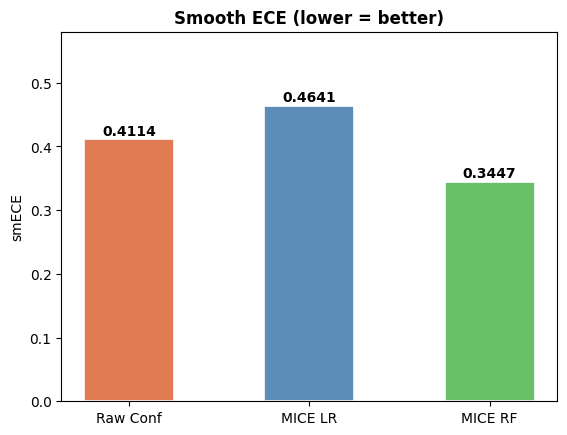

In [ ]:
# smECE bar chart
plt.figure()
labels = ["Raw Conf", "MICE LR", "MICE RF"]
values = [smece_raw, smece_lr, smece_rf]
colors = ["#e07b54", "#5b8db8", "#6abf69"]
bars = plt.bar(labels, values, color=colors, width=0.5, edgecolor="white", linewidth=1.2)
for b, v in zip(bars, values):
    plt.text(b.get_x() + b.get_width()/2, v + 0.002, f"{v:.4f}",
             ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.title("Smooth ECE (lower = better)", fontweight="bold")
plt.ylabel("smECE")
plt.ylim(0, max(values) * 1.25)

plt.show()